In [1]:
# First cell - mount drive
from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install transformers albumentations -q


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip /content/drive/MyDrive/hackathon/Offroad_Segmentation_Training_Dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000123.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000124.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000125.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000126.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000127.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000128.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000129.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000130.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000131.png  
  inflating: 

In [3]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'Offroad' in file or 'Segmentation' in file or 'offroad' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/hackathon/Offroad_Segmentation_Training_Dataset.zip


In [4]:
!unzip /content/drive/MyDrive/hackathon/Offroad_Segmentation_Training_Dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000119.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000120.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000121.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000122.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000123.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000124.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000125.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000126.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000127.png  
  inflating: 

In [5]:
import os

for root, dirs, files in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')

dataset/
  Offroad_Segmentation_Training_Dataset/
    train/
      Color_Images/
      Segmentation/
    val/
      Color_Images/
      Segmentation/


In [2]:
TRAIN_IMAGES = '/content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images'
TRAIN_MASKS  = '/content/dataset/Offroad_Segmentation_Training_Dataset/train/Segmentation'
VAL_IMAGES   = '/content/dataset/Offroad_Segmentation_Training_Dataset/val/Color_Images'
VAL_MASKS    = '/content/dataset/Offroad_Segmentation_Training_Dataset/val/Segmentation'

In [2]:
!pip install transformers albumentations segmentation_models_pytorch -q

In [3]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [4]:
CLASS_MAP = {
    100: 0,    # Trees
    200: 1,    # Lush Bushes
    300: 2,    # Dry Grass
    500: 3,    # Dry Bushes
    550: 4,    # Ground Clutter
    600: 5,    # Flowers
    700: 6,    # Logs
    800: 7,    # Rocks
    7100: 8,   # Landscape
    10000: 9   # Sky
}

def convert_mask(mask_array):
    new_mask = np.zeros_like(mask_array, dtype=np.int64)
    for original_id, new_id in CLASS_MAP.items():
        new_mask[mask_array == original_id] = new_id
    return new_mask

In [7]:
train_images = os.listdir(TRAIN_IMAGES)
train_masks  = os.listdir(TRAIN_MASKS)
val_images   = os.listdir(VAL_IMAGES)

print(f"Train images : {len(train_images)}")
print(f"Train masks  : {len(train_masks)}")
print(f"Val images   : {len(val_images)}")

# Peek at file names
print(f"\nSample image name : {train_images[0]}")
print(f"Sample mask name  : {train_masks[0]}")

Train images : 2857
Train masks  : 2857
Val images   : 317

Sample image name : mt10000585.png
Sample mask name  : mt10000585.png


Unique values in mask: [  100   200   300   550   700   800  7100 10000]


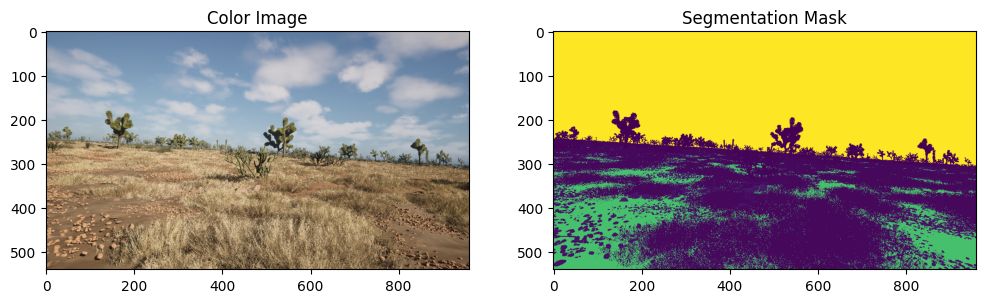

In [11]:
import matplotlib.pyplot as plt

# Load one image and its mask
img  = Image.open(os.path.join(TRAIN_IMAGES, train_images[0]))
mask = Image.open(os.path.join(TRAIN_MASKS,  train_masks[0]))

mask_array = np.array(mask)
print(f"Unique values in mask: {np.unique(mask_array)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Color Image')
axes[1].imshow(mask_array)
axes[1].set_title('Segmentation Mask')
plt.show()

In [12]:
class DesertDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images_dir = images_dir
        self.masks_dir  = masks_dir
        self.transform  = transform
        self.filenames  = sorted(os.listdir(images_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]

        img  = np.array(Image.open(
                   os.path.join(self.images_dir, fname)
               ).convert('RGB'))
        mask = np.array(Image.open(
                   os.path.join(self.masks_dir, fname)
               ))

        # Convert mask IDs to 0-9
        mask = convert_mask(mask)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented['image']
            mask = augmented['mask']

        return img, mask

In [5]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.RandomShadow(p=0.3),          # rocks/trees cast shadows
    A.RandomSunFlare(p=0.2),        # desert sunlight
    A.GaussianBlur(p=0.2),
    A.ColorJitter(
        hue=0.1,
        saturation=0.2,
        p=0.3
    ),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

In [18]:
train_dataset = DesertDataset(TRAIN_IMAGES, TRAIN_MASKS, train_transform)
val_dataset   = DesertDataset(VAL_IMAGES,   VAL_MASKS,   val_transform)

train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True,
                           num_workers=2, drop_last=True)   # ✅ added
val_loader    = DataLoader(val_dataset,   batch_size=8, shuffle=False,
                           num_workers=2, drop_last=True)   # ✅ added

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 357
Val batches   : 39


In [6]:
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

model = smp.DeepLabV3Plus(
    encoder_name="resnet50",        # backbone
    encoder_weights="imagenet",     # pretrained on imagenet
    in_channels=3,                  # RGB images
    classes=10,                     # our 10 desert classes
)
model = model.to(device)

print("DeepLabV3+ ready!")

Using: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DeepLabV3+ ready!


In [16]:
def calculate_iou(pred_mask, true_mask, num_classes=10):
    iou_per_class = []

    for cls in range(num_classes):
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)

        intersection = (pred_cls & true_cls).sum()
        union        = (pred_cls | true_cls).sum()

        if union == 0:
            iou_per_class.append(float('nan'))
        else:
            iou_per_class.append(
                (intersection / union).item()
            )

    mean_iou = np.nanmean(iou_per_class)
    return mean_iou, iou_per_class

In [20]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class_weights = torch.tensor([
    1.0,  # Trees
    1.0,  # Lush Bushes
    1.0,  # Dry Grass
    1.5,  # Dry Bushes
    1.5,  # Ground Clutter
    3.0,  # Flowers (rare!)
    3.0,  # Logs (rare!)
    2.0,  # Rocks
    0.5,  # Landscape
    0.5,  # Sky
]).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

EPOCHS = 5
best_iou = 0.0

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device).long()

        optimizer.zero_grad()
        output = model(imgs)          # ✅ changed line
        loss   = criterion(output, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- Validation ---
    model.eval()
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs   = imgs.to(device)
            output = model(imgs)      # ✅ changed line
            preds  = output.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_masks.append(masks)

    all_preds = torch.cat(all_preds)
    all_masks = torch.cat(all_masks)
    mean_iou, per_class_iou = calculate_iou(all_preds, all_masks)

    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Loss: {train_loss/len(train_loader):.4f} | "
          f"Mean IoU: {mean_iou:.4f}")

    if mean_iou > best_iou:
        best_iou = mean_iou
        torch.save(
            model.state_dict(),
            '/content/drive/MyDrive/hackathon/best_model.pth'
        )
        print(f"  ✅ New best model saved! IoU: {best_iou:.4f}")

Epoch 1/5 | Loss: 0.5614 | Mean IoU: 0.5604
  ✅ New best model saved! IoU: 0.5604
Epoch 2/5 | Loss: 0.5202 | Mean IoU: 0.5764
  ✅ New best model saved! IoU: 0.5764
Epoch 3/5 | Loss: 0.5033 | Mean IoU: 0.5694
Epoch 4/5 | Loss: 0.4941 | Mean IoU: 0.5774
  ✅ New best model saved! IoU: 0.5774
Epoch 5/5 | Loss: 0.4845 | Mean IoU: 0.5857
  ✅ New best model saved! IoU: 0.5857


10 more epochs

In [21]:
# Load best saved model
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/hackathon/best_model.pth'
))
model = model.to(device)
print("Model loaded! Continuing from epoch 5...")

# Continue for 10 more epochs (5 done + 10 = 15 total)
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class_weights = torch.tensor([
    1.0,  # Trees
    1.0,  # Lush Bushes
    1.0,  # Dry Grass
    1.5,  # Dry Bushes
    1.5,  # Ground Clutter
    3.0,  # Flowers (rare!)
    3.0,  # Logs (rare!)
    2.0,  # Rocks
    0.5,  # Landscape
    0.5,  # Sky
]).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10)  # remaining epochs

EPOCHS = 10  # 10 more epochs
best_iou = 0.5857  # starting from your best score

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device).long()

        optimizer.zero_grad()
        output = model(imgs)
        loss   = criterion(output, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs   = imgs.to(device)
            output = model(imgs)
            preds  = output.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_masks.append(masks)

    all_preds = torch.cat(all_preds)
    all_masks = torch.cat(all_masks)
    mean_iou, per_class_iou = calculate_iou(all_preds, all_masks)

    scheduler.step()

    print(f"Epoch {epoch+6}/{15} | "   # starts from 6
          f"Loss: {train_loss/len(train_loader):.4f} | "
          f"Mean IoU: {mean_iou:.4f}")

    if mean_iou > best_iou:
        best_iou = mean_iou
        torch.save(
            model.state_dict(),
            '/content/drive/MyDrive/hackathon/best_model.pth'
        )
        print(f"  ✅ New best model saved! IoU: {best_iou:.4f}")

Model loaded! Continuing from epoch 5...
Epoch 6/15 | Loss: 0.4756 | Mean IoU: 0.5914
  ✅ New best model saved! IoU: 0.5914
Epoch 7/15 | Loss: 0.4668 | Mean IoU: 0.6005
  ✅ New best model saved! IoU: 0.6005
Epoch 8/15 | Loss: 0.4647 | Mean IoU: 0.5939
Epoch 9/15 | Loss: 0.4471 | Mean IoU: 0.6032
  ✅ New best model saved! IoU: 0.6032
Epoch 10/15 | Loss: 0.4407 | Mean IoU: 0.6087
  ✅ New best model saved! IoU: 0.6087
Epoch 11/15 | Loss: 0.4350 | Mean IoU: 0.6061
Epoch 12/15 | Loss: 0.4305 | Mean IoU: 0.6118
  ✅ New best model saved! IoU: 0.6118
Epoch 13/15 | Loss: 0.4260 | Mean IoU: 0.6152
  ✅ New best model saved! IoU: 0.6152
Epoch 14/15 | Loss: 0.4244 | Mean IoU: 0.6151
Epoch 15/15 | Loss: 0.4225 | Mean IoU: 0.6153
  ✅ New best model saved! IoU: 0.6153


In [22]:
CLASS_NAMES = [
    'Trees', 'Lush Bushes', 'Dry Grass', 'Dry Bushes',
    'Ground Clutter', 'Flowers', 'Logs', 'Rocks',
    'Landscape', 'Sky'
]

print("\nPer Class IoU:")
print("-" * 30)
for name, iou in zip(CLASS_NAMES, per_class_iou):
    if np.isnan(iou):
        print(f"{name:20s}: Not present in val set")
    else:
        bar = '█' * int(iou * 20)
        print(f"{name:20s}: {iou:.4f} {bar}")

print(f"\nFinal Mean IoU: {best_iou:.4f}")


Per Class IoU:
------------------------------
Trees               : 0.8340 ████████████████
Lush Bushes         : 0.6780 █████████████
Dry Grass           : 0.6863 █████████████
Dry Bushes          : 0.4830 █████████
Ground Clutter      : 0.3658 ███████
Flowers             : 0.5528 ███████████
Logs                : 0.4907 █████████
Rocks               : 0.4696 █████████
Landscape           : 0.6119 ████████████
Sky                 : 0.9814 ███████████████████

Final Mean IoU: 0.6153


doing 10 more epochs

In [23]:
# Load best saved model
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/hackathon/best_model.pth'
))
model = model.to(device)
print("Model loaded! Continuing from epoch 15...")

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class_weights = torch.tensor([
    1.0,  # Trees
    1.0,  # Lush Bushes
    1.0,  # Dry Grass
    1.5,  # Dry Bushes
    1.5,  # Ground Clutter
    3.0,  # Flowers
    3.0,  # Logs
    2.0,  # Rocks
    0.5,  # Landscape
    0.5,  # Sky
]).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10
best_iou = 0.6153

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device).long()

        optimizer.zero_grad()
        output = model(imgs)
        loss   = criterion(output, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs   = imgs.to(device)
            output = model(imgs)
            preds  = output.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_masks.append(masks)

    all_preds = torch.cat(all_preds)
    all_masks = torch.cat(all_masks)
    mean_iou, per_class_iou = calculate_iou(all_preds, all_masks)

    scheduler.step()

    print(f"Epoch {epoch+16}/{25} | "
          f"Loss: {train_loss/len(train_loader):.4f} | "
          f"Mean IoU: {mean_iou:.4f}")

    if mean_iou > best_iou:
        best_iou = mean_iou
        torch.save(
            model.state_dict(),
            '/content/drive/MyDrive/hackathon/best_model.pth'
        )
        print(f"  ✅ New best model saved! IoU: {best_iou:.4f}")

Model loaded! Continuing from epoch 15...
Epoch 16/25 | Loss: 0.4340 | Mean IoU: 0.5980
Epoch 17/25 | Loss: 0.4446 | Mean IoU: 0.6096
Epoch 18/25 | Loss: 0.4297 | Mean IoU: 0.6189
  ✅ New best model saved! IoU: 0.6189
Epoch 19/25 | Loss: 0.4229 | Mean IoU: 0.6163
Epoch 20/25 | Loss: 0.4238 | Mean IoU: 0.6188
Epoch 21/25 | Loss: 0.4135 | Mean IoU: 0.6195
  ✅ New best model saved! IoU: 0.6195
Epoch 22/25 | Loss: 0.4090 | Mean IoU: 0.6222
  ✅ New best model saved! IoU: 0.6222
Epoch 23/25 | Loss: 0.4092 | Mean IoU: 0.6242
  ✅ New best model saved! IoU: 0.6242
Epoch 24/25 | Loss: 0.4063 | Mean IoU: 0.6247
  ✅ New best model saved! IoU: 0.6247
Epoch 25/25 | Loss: 0.4056 | Mean IoU: 0.6243


In [24]:
!unzip /content/drive/MyDrive/hackathon/Offroad_Segmentation_testImages.zip -d /content/test_data

Archive:  /content/drive/MyDrive/hackathon/Offroad_Segmentation_testImages.zip
   creating: /content/test_data/Offroad_Segmentation_testImages/
   creating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000060.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000061.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000062.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000063.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000064.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000065.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000066.png  
  inflating: /content/test_data/Offroad_Segmentation_testImages/Color_Images/0000067.png  
  inflating: /content/test_data/Offroad_Segmentati

class wise IoU after 25 epochs

In [25]:
CLASS_NAMES = [
    'Trees', 'Lush Bushes', 'Dry Grass', 'Dry Bushes',
    'Ground Clutter', 'Flowers', 'Logs', 'Rocks',
    'Landscape', 'Sky'
]

print("\nPer Class IoU:")
print("-" * 30)
for name, iou in zip(CLASS_NAMES, per_class_iou):
    if np.isnan(iou):
        print(f"{name:20s}: Not present in val set")
    else:
        bar = '█' * int(iou * 20)
        print(f"{name:20s}: {iou:.4f} {bar}")

print(f"\nFinal Mean IoU: {best_iou:.4f}")


Per Class IoU:
------------------------------
Trees               : 0.8434 ████████████████
Lush Bushes         : 0.6851 █████████████
Dry Grass           : 0.6911 █████████████
Dry Bushes          : 0.4916 █████████
Ground Clutter      : 0.3738 ███████
Flowers             : 0.5606 ███████████
Logs                : 0.5109 ██████████
Rocks               : 0.4864 █████████
Landscape           : 0.6180 ████████████
Sky                 : 0.9823 ███████████████████

Final Mean IoU: 0.6247


training 10 more epochs with updated weights

In [26]:
# Load best model
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/hackathon/best_model.pth'
))
model = model.to(device)
print("Continuing from epoch 25 with updated weights...")

from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# Updated weights targeting problem classes
class_weights = torch.tensor([
    1.0,  # Trees (great 0.84)
    1.0,  # Lush Bushes (good)
    1.0,  # Dry Grass (good)
    3.0,  # Dry Bushes ← boosted from 1.5
    4.0,  # Ground Clutter ← boosted from 1.5 (worst!)
    2.0,  # Flowers (okay)
    2.5,  # Logs (improving)
    3.0,  # Rocks ← boosted from 2.0
    0.5,  # Landscape (good)
    0.3,  # Sky (almost perfect, reduce)
]).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = Adam(model.parameters(), lr=5e-5)  # lower lr ✅
scheduler = CosineAnnealingLR(optimizer, T_max=10)

EPOCHS = 10
best_iou = 0.6247

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device).long()

        optimizer.zero_grad()
        output = model(imgs)
        loss   = criterion(output, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs   = imgs.to(device)
            output = model(imgs)
            preds  = output.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_masks.append(masks)

    all_preds = torch.cat(all_preds)
    all_masks = torch.cat(all_masks)
    mean_iou, per_class_iou = calculate_iou(all_preds, all_masks)

    scheduler.step()

    print(f"Epoch {epoch+26}/{35} | "
          f"Loss: {train_loss/len(train_loader):.4f} | "
          f"Mean IoU: {mean_iou:.4f}")

    if mean_iou > best_iou:
        best_iou = mean_iou
        torch.save(
            model.state_dict(),
            '/content/drive/MyDrive/hackathon/best_model.pth'
        )
        print(f"  ✅ New best model saved! IoU: {best_iou:.4f}")

Continuing from epoch 25 with updated weights...
Epoch 26/35 | Loss: 0.4968 | Mean IoU: 0.6084
Epoch 27/35 | Loss: 0.4919 | Mean IoU: 0.6104
Epoch 28/35 | Loss: 0.4902 | Mean IoU: 0.6108
Epoch 29/35 | Loss: 0.4860 | Mean IoU: 0.6066


KeyboardInterrupt: 

Testing

In [7]:
TEST_IMAGES = '/content/test_data/Offroad_Segmentation_testImages/Color_Images'
TEST_MASKS  = '/content/test_data/Offroad_Segmentation_testImages/Segmentation'

print(f"Test images: {len(os.listdir(TEST_IMAGES))}")
print(f"Test masks : {len(os.listdir(TEST_MASKS))}")

Test images: 1002
Test masks : 1002


load best model from drive

In [8]:
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/hackathon/best_model.pth'
))
model.eval()
model = model.to(device)
print("Best model loaded! IoU: 0.6247")

Best model loaded! IoU: 0.6247


CRASH

In [ ]:
all_preds = []
all_masks = []

test_files = sorted(os.listdir(TEST_IMAGES))
print(f"Evaluating {len(test_files)} test images...")

for i, fname in enumerate(test_files):
    # Load image
    img = np.array(Image.open(
        os.path.join(TEST_IMAGES, fname)
    ).convert('RGB'))

    # Load mask
    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    mask = convert_mask(mask)

    # Transform
    transformed = val_transform(image=img, mask=mask)
    img_tensor  = transformed['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred   = output.argmax(dim=1).squeeze().cpu()

    all_preds.append(pred)
    all_masks.append(torch.tensor(mask))

    # Progress update every 100 images
    if (i+1) % 100 == 0:
        print(f"  Processed {i+1}/{len(test_files)} images...")

all_preds = torch.stack(all_preds)
all_masks = torch.stack(all_masks)
print("Done! Calculating IoU...")

Evaluating 1002 test images...
  Processed 100/1002 images...
  Processed 200/1002 images...
  Processed 300/1002 images...
  Processed 400/1002 images...
  Processed 500/1002 images...
  Processed 600/1002 images...
  Processed 700/1002 images...
  Processed 800/1002 images...
  Processed 900/1002 images...
  Processed 1000/1002 images...


CRASH

processing the test data in batches

miscellaneous code for session complete retrieval

In [10]:
val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

In [11]:
model.load_state_dict(torch.load(
    '/content/drive/MyDrive/hackathon/best_model.pth'
))
model.eval()
print("Best model loaded! ✅")

Best model loaded! ✅


In [ ]:
all_preds = []
all_masks = []

test_files = sorted(os.listdir(TEST_IMAGES))
print(f"Evaluating {len(test_files)} test images...")

batch_size = 8
imgs_batch = []
masks_batch = []

for i, fname in enumerate(test_files):
    img = np.array(Image.open(
        os.path.join(TEST_IMAGES, fname)
    ).convert('RGB'))

    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    mask = convert_mask(mask)

    transformed = val_transform(image=img, mask=mask)
    imgs_batch.append(transformed['image'])
    masks_batch.append(torch.tensor(mask))

    if len(imgs_batch) == batch_size or i == len(test_files)-1:
        imgs_tensor = torch.stack(imgs_batch).to(device)

        with torch.no_grad():
            output = model(imgs_tensor)
            preds  = output.argmax(dim=1).cpu()

        all_preds.append(preds)
        all_masks.append(torch.stack(masks_batch))

        imgs_batch  = []
        masks_batch = []
        torch.cuda.empty_cache()

    if (i+1) % 100 == 0:
        print(f"Processed {i+1}/{len(test_files)}...")

all_preds = torch.cat(all_preds)
all_masks = torch.cat(all_masks)
print("Done! Calculating IoU...")

Evaluating 1002 test images...
Processed 100/1002...
Processed 200/1002...
Processed 300/1002...
Processed 400/1002...
Processed 500/1002...
Processed 600/1002...
Processed 700/1002...
Processed 800/1002...
Processed 900/1002...
Processed 1000/1002...


processing one image at a time

CRASH

In [ ]:
all_preds = []
all_masks = []

test_files = sorted(os.listdir(TEST_IMAGES))
print(f"Evaluating {len(test_files)} test images...")

for i, fname in enumerate(test_files):
    # Load image
    img = np.array(Image.open(
        os.path.join(TEST_IMAGES, fname)
    ).convert('RGB'))

    # Load mask
    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    mask = convert_mask(mask)

    # Transform
    transformed = val_transform(image=img, mask=mask)
    img_tensor  = transformed['image'].unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(img_tensor)
        pred   = output.argmax(dim=1).squeeze().cpu()

    # Store as numpy to save memory
    all_preds.append(pred.numpy())
    all_masks.append(mask)

    # Clear GPU memory every image
    del img_tensor, output, pred
    torch.cuda.empty_cache()

    if (i+1) % 100 == 0:
        print(f"Processed {i+1}/{len(test_files)}...")

# Convert to tensors at end
all_preds = torch.tensor(np.stack(all_preds))
all_masks = torch.tensor(np.stack(all_masks))
print("Done! Calculating IoU...")

Evaluating 1002 test images...
Processed 100/1002...
Processed 200/1002...
Processed 300/1002...
Processed 400/1002...
Processed 500/1002...
Processed 600/1002...
Processed 700/1002...
Processed 800/1002...
Processed 900/1002...
Processed 1000/1002...


low RAM usage

In [12]:
num_classes = 10
intersection = torch.zeros(num_classes)
union = torch.zeros(num_classes)

test_files = sorted(os.listdir(TEST_IMAGES))
print(f"Evaluating {len(test_files)} test images...")

for i, fname in enumerate(test_files):
    # Load image
    img = np.array(Image.open(
        os.path.join(TEST_IMAGES, fname)
    ).convert('RGB'))

    # Load mask
    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    mask = convert_mask(mask)

    # Transform image only
    transformed = val_transform(image=img, mask=mask)
    img_tensor  = transformed['image'].unsqueeze(0).to(device)

    # ✅ Use transformed mask (already resized to 512x512)
    mask_tensor = torch.tensor(transformed['mask'])

    with torch.no_grad():
        output = model(img_tensor)
        pred   = output.argmax(dim=1).squeeze().cpu()

    # Calculate IoU
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        true_cls = (mask_tensor == cls)
        intersection[cls] += (pred_cls & true_cls).sum()
        union[cls] += (pred_cls | true_cls).sum()

    del img_tensor, output, pred, mask_tensor
    torch.cuda.empty_cache()

    if (i+1) % 100 == 0:
        print(f"Processed {i+1}/{len(test_files)}...")

# Final IoU
CLASS_NAMES = [
    'Trees', 'Lush Bushes', 'Dry Grass', 'Dry Bushes',
    'Ground Clutter', 'Flowers', 'Logs', 'Rocks',
    'Landscape', 'Sky'
]

iou_per_class = []
for cls in range(num_classes):
    if union[cls] == 0:
        iou_per_class.append(float('nan'))
    else:
        iou_per_class.append(
            (intersection[cls] / union[cls]).item()
        )

mean_iou = np.nanmean(iou_per_class)
print(f"\n{'='*40}")
print(f"FINAL TEST Mean IoU: {mean_iou:.4f}")
print(f"{'='*40}")
print("\nPer Class IoU:")
print("-" * 30)
for name, iou in zip(CLASS_NAMES, iou_per_class):
    if np.isnan(iou):
        print(f"{name:20s}: Not present")
    else:
        bar = '█' * int(iou * 20)
        print(f"{name:20s}: {iou:.4f} {bar}")

Evaluating 1002 test images...


/tmp/ipykernel_66766/1141815043.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask_tensor = torch.tensor(transformed['mask'])


Processed 100/1002...
Processed 200/1002...
Processed 300/1002...
Processed 400/1002...
Processed 500/1002...
Processed 600/1002...
Processed 700/1002...
Processed 800/1002...
Processed 900/1002...
Processed 1000/1002...

FINAL TEST Mean IoU: 0.2762

Per Class IoU:
------------------------------
Trees               : 0.3204 ██████
Lush Bushes         : 0.0002 
Dry Grass           : 0.4575 █████████
Dry Bushes          : 0.3412 ██████
Ground Clutter      : 0.0000 
Flowers             : 0.0000 
Logs                : 0.0000 
Rocks               : 0.0330 
Landscape           : 0.6258 ████████████
Sky                 : 0.9838 ███████████████████


In [13]:
import numpy as np
from PIL import Image
import os

# Check first test mask values
mask = np.array(Image.open(
    os.path.join(TEST_MASKS,
    sorted(os.listdir(TEST_MASKS))[0])
))
print(f"Test mask unique values: {np.unique(mask)}")
print(f"Test mask shape: {mask.shape}")

# Compare with training mask
train_mask = np.array(Image.open(
    os.path.join(TRAIN_MASKS,
    sorted(os.listdir(TRAIN_MASKS))[0])
))
print(f"\nTrain mask unique values: {np.unique(train_mask)}")

Test mask unique values: [  100   200   300   500   800  7100 10000]
Test mask shape: (540, 960)

Train mask unique values: [  200   300   500   550   800  7100 10000]


In [19]:
import torch.nn.functional as F

num_classes = 10
intersection = torch.zeros(num_classes)
union = torch.zeros(num_classes)

test_files = sorted(os.listdir(TEST_IMAGES))
print(f"Evaluating {len(test_files)} test images...")

for i, fname in enumerate(test_files):
    # Load image
    img = np.array(Image.open(
        os.path.join(TEST_IMAGES, fname)
    ).convert('RGB'))

    # Load mask - keep ORIGINAL size!
    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    mask = convert_mask(mask)
    original_h, original_w = mask.shape
    mask_tensor = torch.tensor(mask)

    # Transform image only (no mask!)
    img_only_transform = A.Compose([
        A.Resize(512, 512),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])

    transformed = img_only_transform(image=img)
    img_tensor  = transformed['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)

        # ✅ Resize prediction back to original mask size!
        pred = F.interpolate(
            output,
            size=(original_h, original_w),
            mode='bilinear',
            align_corners=False
        ).argmax(dim=1).squeeze().cpu()

    # Calculate IoU
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        true_cls = (mask_tensor == cls)
        intersection[cls] += (pred_cls & true_cls).sum()
        union[cls] += (pred_cls | true_cls).sum()

    del img_tensor, output, pred, mask_tensor
    torch.cuda.empty_cache()

    if (i+1) % 100 == 0:
        print(f"Processed {i+1}/{len(test_files)}...")

# Final IoU
CLASS_NAMES = [
    'Trees', 'Lush Bushes', 'Dry Grass', 'Dry Bushes',
    'Ground Clutter', 'Flowers', 'Logs', 'Rocks',
    'Landscape', 'Sky'
]

iou_per_class = []
for cls in range(num_classes):
    if union[cls] == 0:
        iou_per_class.append(float('nan'))
    else:
        iou_per_class.append(
            (intersection[cls] / union[cls]).item()
        )

mean_iou = np.nanmean(iou_per_class)
print(f"\n{'='*40}")
print(f"FINAL TEST Mean IoU: {mean_iou:.4f}")
print(f"{'='*40}")
print("\nPer Class IoU:")
print("-" * 30)
for name, iou in zip(CLASS_NAMES, iou_per_class):
    if np.isnan(iou):
        print(f"{name:20s}: Not present")
    else:
        bar = '█' * int(iou * 20)
        print(f"{name:20s}: {iou:.4f} {bar}")

Evaluating 1002 test images...
Processed 100/1002...
Processed 200/1002...
Processed 300/1002...
Processed 400/1002...
Processed 500/1002...
Processed 600/1002...
Processed 700/1002...
Processed 800/1002...
Processed 900/1002...
Processed 1000/1002...

FINAL TEST Mean IoU: 0.2774

Per Class IoU:
------------------------------
Trees               : 0.3260 ██████
Lush Bushes         : 0.0002 
Dry Grass           : 0.4597 █████████
Dry Bushes          : 0.3440 ██████
Ground Clutter      : 0.0000 
Flowers             : 0.0000 
Logs                : 0.0000 
Rocks               : 0.0332 
Landscape           : 0.6286 ████████████
Sky                 : 0.9823 ███████████████████


In [15]:
# Check multiple test masks
import random
test_files = sorted(os.listdir(TEST_MASKS))
sample_files = random.sample(test_files, 5)

for fname in sample_files:
    mask = np.array(Image.open(
        os.path.join(TEST_MASKS, fname)
    ))
    print(f"{fname}: {np.unique(mask)}")

0000244.png: [  100   300   500   800  7100 10000]
0000197.png: [  100   200   300   500   800  7100 10000]
0000150.png: [  100   200   300   500   800  7100 10000]
0000786.png: [  100   300   500   800  7100 10000]
0000997.png: [  100   200   300   500   800  7100 10000]


In [16]:
mask = np.array(Image.open(
    os.path.join(TEST_MASKS,
    sorted(os.listdir(TEST_MASKS))[0])
))
print(f"Mask shape: {mask.shape}")
print(f"Mask dtype: {mask.dtype}")
# Should be (H, W) not (H, W, 3)

Mask shape: (540, 960)
Mask dtype: uint16


In [17]:
def convert_mask(mask_array):
    # ✅ Convert to int32 first!
    mask_array = mask_array.astype(np.int32)
    new_mask = np.zeros_like(mask_array, dtype=np.int64)
    for original_id, new_id in CLASS_MAP.items():
        new_mask[mask_array == original_id] = new_id
    return new_mask

In [18]:
# Verify fix works on one mask
mask = np.array(Image.open(
    os.path.join(TEST_MASKS,
    sorted(os.listdir(TEST_MASKS))[0])
))
converted = convert_mask(mask)
print(f"Unique converted values: {np.unique(converted)}")
# Should show: 0,1,2,3,4,5,6,7,8,9

Unique converted values: [0 1 2 3 7 8 9]


In [20]:
# Test convert_mask on actual test mask
test_fname = sorted(os.listdir(TEST_MASKS))[0]
mask_raw = np.array(Image.open(
    os.path.join(TEST_MASKS, test_fname)
))

print(f"Raw mask dtype: {mask_raw.dtype}")
print(f"Raw mask unique: {np.unique(mask_raw)}")

mask_converted = convert_mask(mask_raw)
print(f"Converted unique: {np.unique(mask_converted)}")
print(f"Converted dtype: {mask_converted.dtype}")

# Check if values match correctly
print(f"\nValue 100 count in raw: {(mask_raw == 100).sum()}")
print(f"Value 0 count in converted: {(mask_converted == 0).sum()}")

Raw mask dtype: uint16
Raw mask unique: [  100   200   300   500   800  7100 10000]
Converted unique: [0 1 2 3 7 8 9]
Converted dtype: int64

Value 100 count in raw: 1762
Value 0 count in converted: 1762


Prediction unique values: tensor([0, 1, 2, 3, 4, 7, 8, 9])
Prediction shape: torch.Size([512, 512])


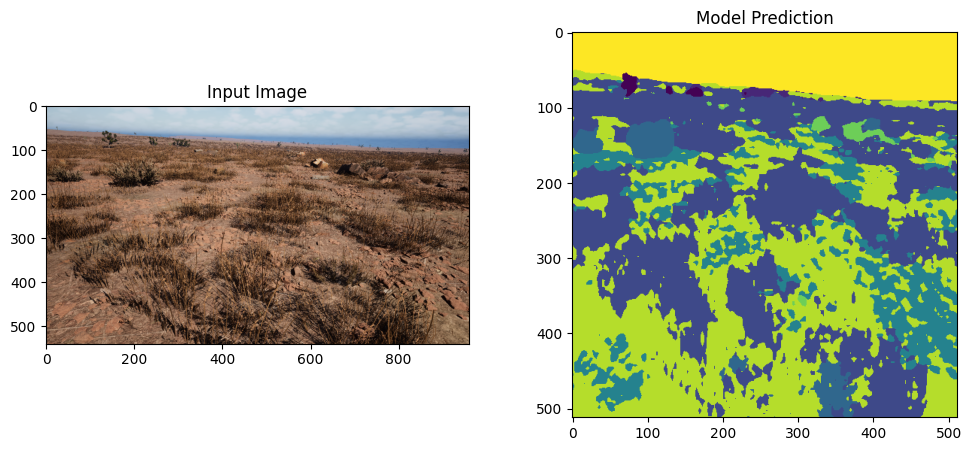

In [21]:
# Check what model is actually predicting
test_fname = sorted(os.listdir(TEST_IMAGES))[0]
img = np.array(Image.open(
    os.path.join(TEST_IMAGES, test_fname)
).convert('RGB'))

# Transform
img_only_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

transformed = img_only_transform(image=img)
img_tensor  = transformed['image'].unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)
    pred   = output.argmax(dim=1).squeeze().cpu()

print(f"Prediction unique values: {torch.unique(pred)}")
print(f"Prediction shape: {pred.shape}")

# Visualize
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title('Input Image')
axes[1].imshow(pred.numpy())
axes[1].set_title('Model Prediction')
plt.show()

In [22]:
# Compare prediction vs ground truth for one image
test_fname = sorted(os.listdir(TEST_IMAGES))[0]
mask_fname = sorted(os.listdir(TEST_MASKS))[0]

print(f"Image: {test_fname}")
print(f"Mask:  {mask_fname}")
print(f"Same file? {test_fname == mask_fname}")

Image: 0000060.png
Mask:  0000060.png
Same file? True


In [23]:
test_image_files = sorted(os.listdir(TEST_IMAGES))
test_mask_files  = sorted(os.listdir(TEST_MASKS))

print("First 5 image files:")
print(test_image_files[:5])

print("\nFirst 5 mask files:")
print(test_mask_files[:5])

print(f"\nTotal images: {len(test_image_files)}")
print(f"Total masks:  {len(test_mask_files)}")

First 5 image files:
['0000060.png', '0000061.png', '0000062.png', '0000063.png', '0000064.png']

First 5 mask files:
['0000060.png', '0000061.png', '0000062.png', '0000063.png', '0000064.png']

Total images: 1002
Total masks:  1002


In [24]:
# Deep comparison for single image
test_fname = '0000060.png'

# Load and convert mask
mask_raw = np.array(Image.open(
    os.path.join(TEST_MASKS, test_fname)
))
mask_converted = convert_mask(mask_raw)

# Load and predict
img = np.array(Image.open(
    os.path.join(TEST_IMAGES, test_fname)
).convert('RGB'))

img_only_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    ToTensorV2()
])

transformed = img_only_transform(image=img)
img_tensor  = transformed['image'].unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)
    import torch.nn.functional as F
    pred = F.interpolate(
        output,
        size=(540, 960),
        mode='bilinear',
        align_corners=False
    ).argmax(dim=1).squeeze().cpu()

print(f"Mask unique:  {np.unique(mask_converted)}")
print(f"Pred unique:  {torch.unique(pred).numpy()}")
print(f"Mask shape:   {mask_converted.shape}")
print(f"Pred shape:   {pred.shape}")

# Manual IoU for this one image
for cls in range(10):
    pred_cls = (pred == cls)
    true_cls = (torch.tensor(mask_converted) == cls)
    intersection = (pred_cls & true_cls).sum().item()
    union = (pred_cls | true_cls).sum().item()
    if union > 0:
        print(f"Class {cls}: IoU = {intersection/union:.4f} "
              f"| pred_pixels={pred_cls.sum().item()} "
              f"| true_pixels={true_cls.sum().item()}")

Mask unique:  [0 1 2 3 7 8 9]
Pred unique:  [0 1 2 3 4 7 8 9]
Mask shape:   (540, 960)
Pred shape:   torch.Size([540, 960])
Class 0: IoU = 0.4134 | pred_pixels=1479 | true_pixels=1762
Class 1: IoU = 0.0000 | pred_pixels=1552 | true_pixels=12
Class 2: IoU = 0.4275 | pred_pixels=183577 | true_pixels=127567
Class 3: IoU = 0.2399 | pred_pixels=15372 | true_pixels=12170
Class 4: IoU = 0.0000 | pred_pixels=62443 | true_pixels=0
Class 7: IoU = 0.0355 | pred_pixels=3664 | true_pixels=78721
Class 8: IoU = 0.4866 | pred_pixels=174265 | true_pixels=224077
Class 9: IoU = 0.9742 | pred_pixels=76048 | true_pixels=74091
